# Overfitting, Underfitting, and Regularization

## Learning Objectives
- Understand overfitting and underfitting concepts.
- Learn common regularization techniques to improve generalization.

## Introduction
Overfitting occurs when a model captures noise instead of the underlying pattern. Underfitting happens when a model is too simple. Regularization techniques help manage this balance.

## Core Concepts
- **Overfitting:** Model performs well on training but poorly on new data.
- **Underfitting:** Model performs poorly on both training and test data.
- **Regularization:** Techniques like L1 (Lasso), L2 (Ridge) add penalties to model complexity.
- **Early Stopping:** Halting training before overfitting.
- **Cross-validation:** Assists in detecting overfitting.


In [3]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create synthetic regression data
X, y = make_regression(n_samples=100, n_features=20, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_train = ridge.predict(X_train)
pred_test = ridge.predict(X_test)

print(f"Train MSE: {mean_squared_error(y_train, pred_train):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, pred_test):.4f}")

Train MSE: 5.5175
Test MSE: 5.3442


More examples

RidgeCV found the best alpha: 10.0000
LassoCV found the best alpha: 1.0000
Gradient Boosting stopped early at 76 estimators.

Final Model Performance Metrics
--- Linear Regression ---
Test MSE: 2666.72 | Test R²: 0.92

--- Ridge (CV) ---
Test MSE: 2331.54 | Test R²: 0.93

--- Lasso (CV) ---
Test MSE: 679.62 | Test R²: 0.98

--- Gradient Boosting (ES) ---
Test MSE: 11604.08 | Test R²: 0.66



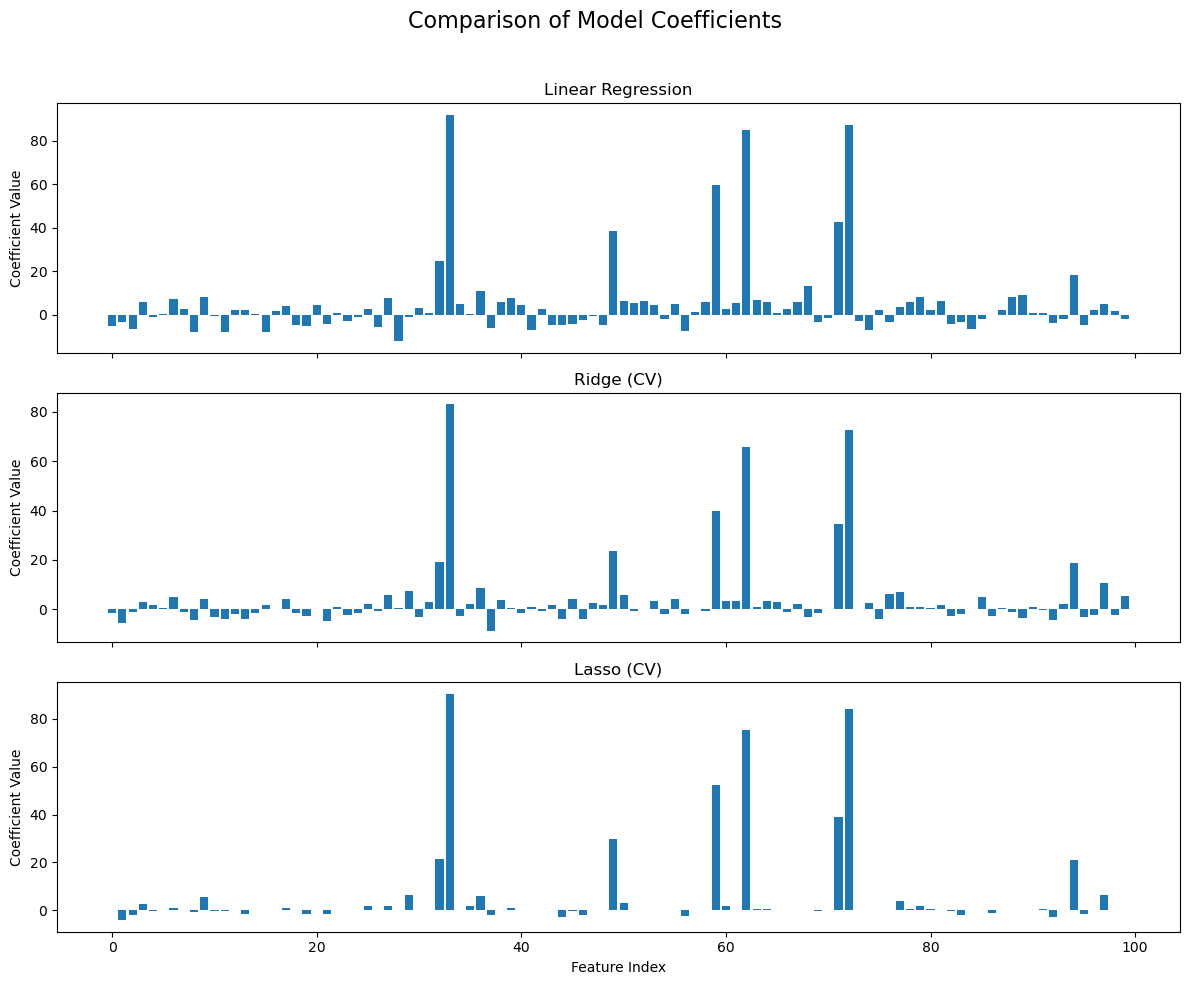

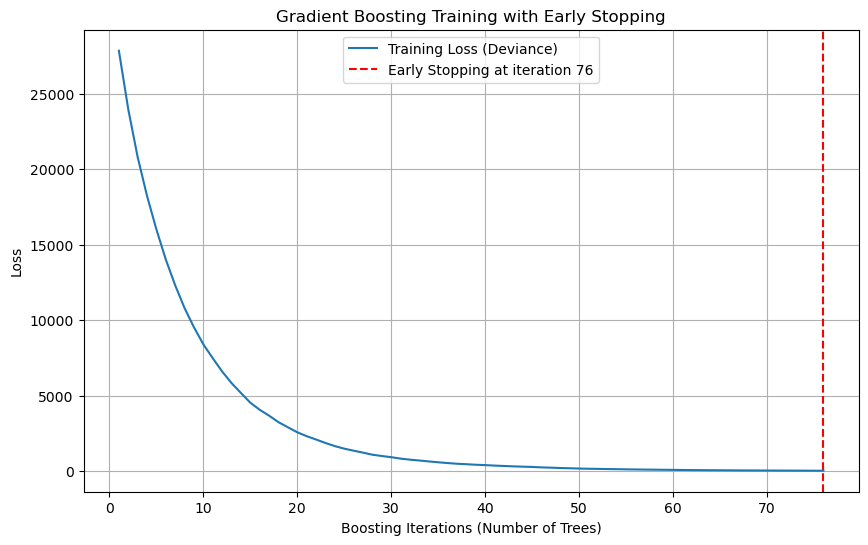

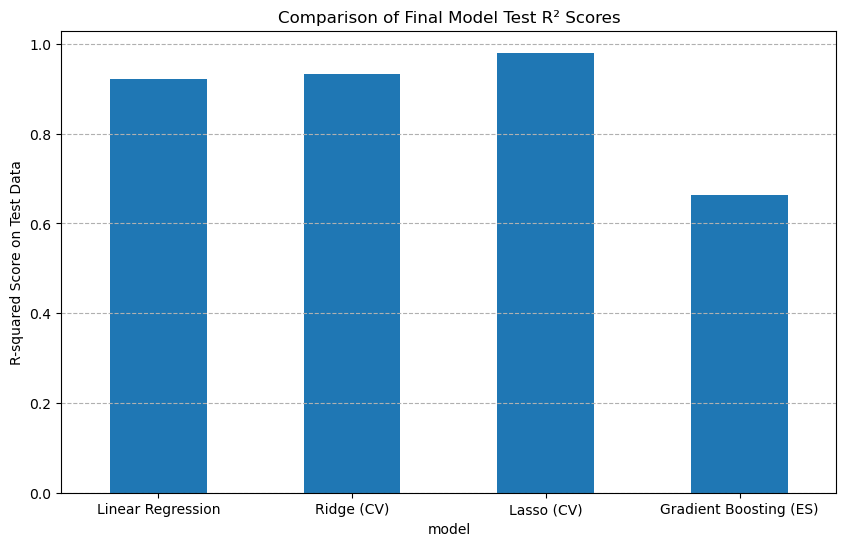

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Create Synthetic Data Prone to Overfitting ---
X, y = make_regression(
    n_samples=150,
    n_features=100,
    n_informative=10,
    noise=25,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- 2. Define and Train Models ---

# --- Model A: Unregularized Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)

# --- Model B & C: Regularization with Cross-Validation ---
alphas_to_test = np.logspace(-6, 6, 13)

# RidgeCV (Corrected: removed store_cv_values)
# This will now work on older versions of scikit-learn.
ridge_cv = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_cv.fit(X_train, y_train)
print(f"RidgeCV found the best alpha: {ridge_cv.alpha_:.4f}")

# LassoCV
lasso_cv = LassoCV(alphas=alphas_to_test, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print(f"LassoCV found the best alpha: {lasso_cv.alpha_:.4f}")


# --- Model D: Gradient Boosting with Early Stopping ---
gbr = GradientBoostingRegressor(
    n_estimators=500,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=0.01,
    random_state=42
)
gbr.fit(X_train, y_train)
print(f"Gradient Boosting stopped early at {gbr.n_estimators_} estimators.")


# --- 3. Evaluate Final Model Performance ---
models = {
    'Linear Regression': lr,
    'Ridge (CV)': ridge_cv,
    'Lasso (CV)': lasso_cv,
    'Gradient Boosting (ES)': gbr
}
results = []
print("\n" + "="*30)
print("Final Model Performance Metrics")
print("="*30)
for name, model in models.items():
    y_pred_test = model.predict(X_test)
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    print(f"--- {name} ---")
    print(f"Test MSE: {test_mse:.2f} | Test R²: {test_r2:.2f}\n")
    results.append({'model': name, 'Test R²': test_r2})


# --- 4. Visualizations ---

# A. Coefficient Plot (for Linear, Ridge, Lasso)
coefficients = pd.DataFrame({
    'Linear Regression': lr.coef_,
    'Ridge (CV)': ridge_cv.coef_,
    'Lasso (CV)': lasso_cv.coef_
})
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Comparison of Model Coefficients', fontsize=16)
for i, model_name in enumerate(coefficients.columns):
    axes[i].bar(range(coefficients.shape[0]), coefficients[model_name])
    axes[i].set_title(model_name)
    axes[i].set_ylabel('Coefficient Value')
axes[2].set_xlabel('Feature Index')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# B. Early Stopping Visualization
train_loss = gbr.train_score_
stop_iteration = gbr.n_estimators_
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss (Deviance)')
plt.axvline(stop_iteration, color='r', linestyle='--', label=f'Early Stopping at iteration {stop_iteration}')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Loss')
plt.title('Gradient Boosting Training with Early Stopping')
plt.legend()
plt.grid(True)
plt.show()


# C. Final Performance Comparison
results_df = pd.DataFrame(results)
results_df.set_index('model').plot(kind='bar', figsize=(10, 6), legend=False)
plt.title('Comparison of Final Model Test R² Scores')
plt.ylabel('R-squared Score on Test Data')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

## Exercise
Try Lasso regression with different alpha values and observe changes in model sparsity.

In [ ]:
# Your code here

## Summary
- Balancing bias and variance is key to good model performance.
- Regularization prevents overfitting by penalizing complexity.


## Further Reading
- [Overfitting and Underfitting - scikit-learn](https://scikit-learn.org/stable/tutorial/basic/tutorial.html#overfitting-and-underfitting)
- [Regularization Techniques](https://towardsdatascience.com/regularization-in-machine-learning-76441ddcf99a)
